[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mansamoussa/zebrAssist/blob/master/notebooks/1_Yolo_Pre_Finetuning.ipynb)

In [7]:
# YOLOv10 Training - Using Existing YOLO Dataset Structure
# Train directly on your pre-structured dataset

# =============================================================================
# STEP 1: Setup and Installation
# =============================================================================

# Mount Google Drive
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    dataset_path = '/content/drive/MyDrive/Computer_Vision_Project/data/ZebrAssist_YOLO_PartialAnnotations'
    yaml_path = f'{dataset_path}/data.yaml'
    temp_yaml_path = '/content/data.yaml'
    # Install required packages
    !pip install ultralytics

else:
    dataset_path = '../data/ZebrAssistSwiss_YOLO_120'
    yaml_path = f'{dataset_path}/data.yaml'
    temp_yaml_path = '../data/data.yaml'



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Import libraries
import os
import yaml
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

In [9]:
# =============================================================================
# STEP 2: Verify Dataset Structure
# =============================================================================

# Check if dataset exists
if os.path.exists(dataset_path):
    print("✅ Dataset directory found!")

    # List contents
    contents = os.listdir(dataset_path)
    print(f"Contents: {contents}")

    # Check for required files/folders
    required_items = ['data.yaml', 'train']
    for item in required_items:
        if item in contents:
            print(f"✅ Found: {item}")
        else:
            print(f"❌ Missing: {item}")

    # Check train folder structure
    train_path = f'{dataset_path}/train'
    if os.path.exists(train_path):
        train_contents = os.listdir(train_path)
        print(f"Train folder contents: {train_contents}")

        # Count images and labels
        images_path = f'{train_path}/images'
        labels_path = f'{train_path}/labels'

        if os.path.exists(images_path):
            train_images = [f for f in os.listdir(images_path)]
            print(f"📸 Found {len(train_images)} images")

        if os.path.exists(labels_path):
            txt_files = [f for f in os.listdir(labels_path) if f.endswith('.txt')]
            print(f"🏷️ Found {len(txt_files)} .txt label files")
else:
    print("❌ Dataset directory not found!")

✅ Dataset directory found!
Contents: ['train', 'val', 'data.yaml']
✅ Found: data.yaml
✅ Found: train
Train folder contents: ['images', 'labels', 'labels.cache']
📸 Found 12 images
🏷️ Found 12 .txt label files


In [10]:
# =============================================================================
# STEP 3: Read and Verify YAML Configuration
# =============================================================================

if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    print("\n📋 Current dataset configuration:")
    print(yaml.dump(data_config, default_flow_style=False))

    # Update paths to absolute paths if they're relative
    if not os.path.isabs(data_config.get('train', '')):
        data_config['train'] = f"{dataset_path}/{data_config['train']}"
    if 'val' in data_config and len(data_config['val']) > 0 and not os.path.isabs(data_config.get('val', ''))   :
        print("⚠️ Validation set specified in YAML.")
        data_config['val'] = f"{dataset_path}/{data_config['val']}"
    else:
        print("⚠️ No validation set specified in YAML.")
        data_config['val'] = data_config['train']  # Will auto-split if val=train

    # Save updated config
    with open(temp_yaml_path, 'w') as f:
        yaml.dump(data_config, f)

    print(f"\n📝 Updated configuration saved to: {temp_yaml_path}")

else:
    print("❌ data.yaml file not found!")


📋 Current dataset configuration:
names:
  0: object
path: /content/drive/MyDrive/Computer_Vision_Project/data/ZebrAssist_YOLO_PartialAnnotations
train: train/images
val: val/images

⚠️ Validation set specified in YAML.

📝 Updated configuration saved to: /content/data.yaml


In [11]:
# =============================================================================
# STEP 4: Initialize and Train YOLOv10
# =============================================================================

# Initialize YOLOv10 model
print("\n🚀 Initializing YOLOv10...")
model = YOLO('yolov10n.pt')  # Using nano version - change to 's', 'm', 'l', 'x' for larger models


🚀 Initializing YOLOv10...


In [12]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device ='cpu'

In [13]:
# Training parameters optimized for small dataset (15 images)
training_args = {
    'data': temp_yaml_path,    # Use yaml_path OR temp_yaml_path
    'epochs': 100,        # More epochs for small dataset
    'imgsz': 640,         # Image size
    'batch': 2,           # Very small batch size for limited data
    'patience': 30,       # Early stopping patience
    'save_period': 25,    # Save checkpoint every 25 epochs
    'device': device,          # Use GPU if available
    'workers': 2,         # Number of workers
    # 'project': '/content/yolo_training',
    'name': f'zebrAssist_{len(train_images)}_images',
    'exist_ok': True,
    'optimizer': 'AdamW',
    'lr0': 0.0005,        # Lower learning rate for small dataset
    'weight_decay': 0.0005,
    'warmup_epochs': 5,
    'box': 7.5,           # Box loss gain
    'cls': 0.5,           # Classification loss gain
    'dfl': 1.5,           # Distribution focal loss gain
    # Data augmentation (important for small datasets)
    'hsv_h': 0.015,       # HSV-Hue augmentation
    'hsv_s': 0.7,         # HSV-Saturation augmentation
    'hsv_v': 0.4,         # HSV-Value augmentation
    'degrees': 10.0,      # Rotation augmentation
    'translate': 0.1,     # Translation augmentation
    'scale': 0.2,         # Scale augmentation
    'fliplr': 0.5,        # Horizontal flip
    'mosaic': 0.8,        # Mosaic augmentation
    'mixup': 0.1,         # Mixup augmentation
    'copy_paste': 0.1,    # Copy-paste augmentation
}

print("Training parameters:")
for key, value in training_args.items():
    print(f"  {key}: {value}")

Training parameters:
  data: /content/data.yaml
  epochs: 100
  imgsz: 640
  batch: 2
  patience: 30
  save_period: 25
  device: cpu
  workers: 2
  name: zebrAssist_12_images
  exist_ok: True
  optimizer: AdamW
  lr0: 0.0005
  weight_decay: 0.0005
  warmup_epochs: 5
  box: 7.5
  cls: 0.5
  dfl: 1.5
  hsv_h: 0.015
  hsv_s: 0.7
  hsv_v: 0.4
  degrees: 10.0
  translate: 0.1
  scale: 0.2
  fliplr: 0.5
  mosaic: 0.8
  mixup: 0.1
  copy_paste: 0.1


In [14]:
# =============================================================================
# STEP 5: Start Training
# =============================================================================

print("\n🎯 Starting training...")

try:
    # Train the model
    # results = model.train(data=yaml_path, epochs=100, imgsz=640, batch=8, device=0 if torch.cuda.is_available() else 'cpu')
    results = model.train(**training_args)
    print("✅ Training completed successfully!")

    # Training results summary
    print(f"\n📊 Training Results:")
    print(f"Best weights: {results.save_dir}/weights/best.pt")
    print(f"Last weights: {results.save_dir}/weights/last.pt")

except Exception as e:
    print(f"❌ Training failed: {str(e)}")
    print("Common issues:")
    print("- Check that data.yaml paths are correct")
    print("- Verify image and label files exist and match")
    print("- Ensure YOLO annotation format is correct")


🎯 Starting training...
Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=10.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=0.8, multi_scale=False, name=zebrAssist_12_images, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, p

In [15]:
# To display plots in notebook
%matplotlib inline

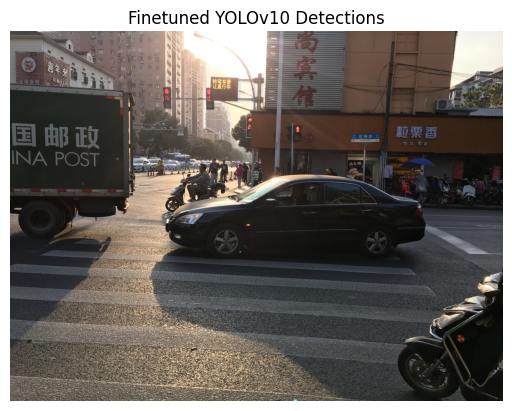

In [21]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Lade bestes Modell
best_model_path = f'./runs/detect/{training_args["name"]}/weights/best.pt'
best_model = YOLO(best_model_path)

# Testbild-Pfad (korrekt nur EIN Pfad angeben!)
test_img_path = '/content/drive/MyDrive/Computer_Vision_Project/data/ZebrAssist_YOLO_PartialAnnotations/train/images/heon_IMG_0549.JPG'


# Visualisieren
annotated = results_test[0].plot()
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title('Finetuned YOLOv10 Detections')
plt.axis('off')
plt.show()



🔍 Loading trained model for validation...
Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv10n summary (fused): 102 layers, 2,265,363 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 298.6±191.7 MB/s, size: 3729.8 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1XWw4fflVG0bDYV4jiWOZW18kLqtRiaHC/Computer_Vision_Project/data/ZebrAssist_YOLO_PartialAnnotations/val/labels.cache... 12 images, 0 backgrounds, 5 corrupt: 100% ━━━━━━━━━━━━ 12/12 18.5Kit/s 0.0s
val: /content/drive/.shortcut-targets-by-id/1XWw4fflVG0bDYV4jiWOZW18kLqtRiaHC/Computer_Vision_Project/data/ZebrAssist_YOLO_PartialAnnotations/val/images/heon_IMG_0549.JPG: ignoring corrupt image/label: Label class 2 exceeds dataset class count 1. Possible class labels are 0-0
val: /content/drive/.shortcut-targets-by-id/1XWw4fflVG0bDYV4jiWOZW18kLqtRiaHC/Computer_Vision_Project/data/ZebrAssist_YOLO_PartialAnnotations/val/images/heon_IMG_0553.JPG: ignori

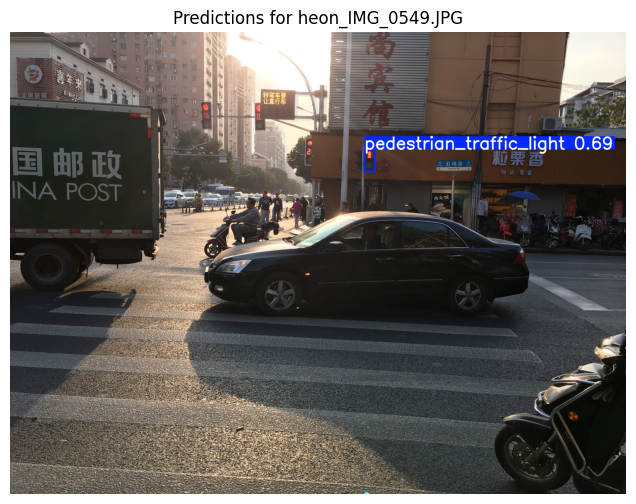

Detections in heon_IMG_0549.JPG:
  - pedestrian_traffic_light: 0.695

image 1/1 /content/drive/MyDrive/Computer_Vision_Project/data/ZebrAssist_YOLO_PartialAnnotations/val/images/heon_IMG_0566.JPG: 480x640 (no detections), 112.2ms
Speed: 3.6ms preprocess, 112.2ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)


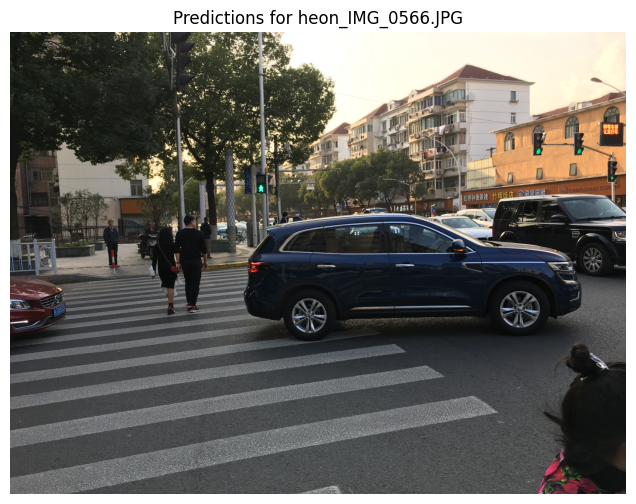

No detections in heon_IMG_0566.JPG

image 1/1 /content/drive/MyDrive/Computer_Vision_Project/data/ZebrAssist_YOLO_PartialAnnotations/val/images/heon_IMG_0559.JPG: 480x640 1 pedestrian_traffic_light, 101.3ms
Speed: 3.7ms preprocess, 101.3ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)


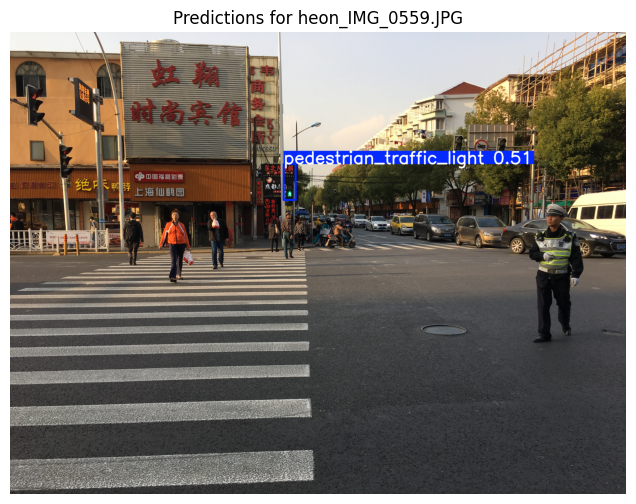

Detections in heon_IMG_0559.JPG:
  - pedestrian_traffic_light: 0.509


In [26]:
# =============================================================================
# STEP 6: Validate and Test Model
# =============================================================================
if IN_COLAB:
    best_model_path = f'/content/drive/MyDrive/Computer_Vision_Project/trained_models/1_Yolo_FineTuned/weights/best.pt'
else:
    best_model_path = f'./runs/detect/{training_args["name"]}/weights/best.pt'

if os.path.exists(best_model_path):
    print("\n🔍 Loading trained model for validation...")
    trained_model = YOLO(best_model_path)

    # Validate the model (erzwinge CPU)
    val_results = trained_model.val(data=temp_yaml_path, device="cpu")

    print(f"\n📈 Validation Metrics:")
    print(f"mAP@0.5: {val_results.box.map50:.4f}")
    print(f"mAP@0.5:0.95: {val_results.box.map:.4f}")
    print(f"Precision: {val_results.box.mp:.4f}")
    print(f"Recall: {val_results.box.mr:.4f}")

    # Test on validation images (since dataset is small)
    print("\n🖼️ Testing predictions on sample validation images...")

    images_dir = f'{dataset_path}/val/images'
    sample_images = [f for f in os.listdir(images_dir)][:3]

    for img_name in sample_images:
        img_path = os.path.join(images_dir, img_name)

        # Run prediction (CPU + confidence threshold)
        results = trained_model(img_path, conf=0.25, device="cpu")

        # Display results
        annotated = results[0].plot()
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f'Predictions for {img_name}')
        plt.show()

        # Print detections
        boxes = results[0].boxes
        if boxes is not None and len(boxes) > 0:
            print(f"Detections in {img_name}:")
            for i, box in enumerate(boxes):
                class_id = int(box.cls[0])
                confidence = float(box.conf[0])
                class_name = trained_model.names[class_id]
                print(f"  - {class_name}: {confidence:.3f}")
        else:
            print(f"No detections in {img_name}")

else:
    print("❌ Trained model weights not found. Cannot validate or test.")


In [27]:
# =============================================================================
# STEP 7: Save Model to Google Drive
# =============================================================================

if os.path.exists(best_model_path):
    # Create folder for trained models in your Google Drive
    output_dir = '/content/drive/MyDrive/Computer_Vision_Project/trained_models'
    os.makedirs(output_dir, exist_ok=True)

    # Copy best model
    import shutil
    output_model_path = f'{output_dir}/yolov10_zebraassist_best.pt'
    shutil.copy2(best_model_path, output_model_path)

    print(f"✅ Trained model saved to: {output_model_path}")

    # Export to ONNX for deployment
    try:
        trained_model.export(format='onnx', dynamic=True)
        onnx_source = best_model_path.replace('.pt', '.onnx')
        if os.path.exists(onnx_source):
            shutil.copy2(onnx_source, f'{output_dir}/yolov10_zebraassist_best.onnx')
            print(f"✅ ONNX model saved to: {output_dir}/yolov10_zebraassist_best.onnx")
    except Exception as e:
        print(f"ONNX export failed: {e}")

print(f"\n🎉 Training complete! Check your results in Google Drive at:")
print(f"{output_dir}/")

✅ Trained model saved to: /content/drive/MyDrive/Computer_Vision_Project/trained_models/yolov10_zebraassist_best.pt
Ultralytics 8.3.201 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/Computer_Vision_Project/trained_models/1_Yolo_FineTuned/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.67', 'onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 4.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.0 opset 19...
ONNX: slimming with onnxslim 0.1.68...
ONNX: export success ✅ 8.0s, saved as '/content/drive/MyDrive/Computer_Vision_Project/trained_models/1_Yol


image 1/1 /content/drive/MyDrive/Computer_Vision_Project/data/imVisible/PTL_Dataset_4032x3024_Part1/heon_IMG_0602.JPG: 480x640 1 pedestrian_traffic_light, 120.7ms
Speed: 4.5ms preprocess, 120.7ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


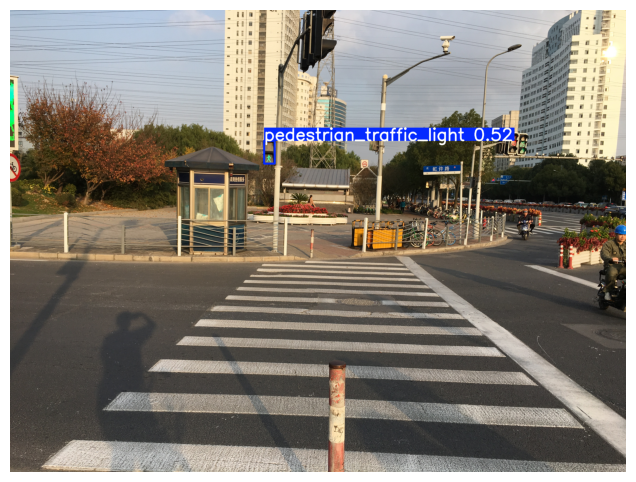

In [31]:
# =============================================================================
# STEP 8: Quick Inference Function for Future Use
# =============================================================================

def quick_predict(image_path, confidence=0.25):
    """Quick prediction function using your trained model"""
    if IN_COLAB:
        model_path = '/content/drive/MyDrive/Computer_Vision_Project/trained_models/1_Yolo_FineTuned/weights/best.pt'
    else:
        model_path = './runs/detect/zebraassist_15images/weights/best.pt'

    if os.path.exists(model_path):
        model = YOLO(model_path)
        # Erzwinge CPU, um den CUDA-Fehler zu vermeiden
        results = model(image_path, conf=confidence, device="cpu")

        # Show results
        annotated = results[0].plot()
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

        return results
    else:
        print("❌ Trained model not found!")

# Usage example:
if IN_COLAB:
    quick_predict('/content/drive/MyDrive/Computer_Vision_Project/data/imVisible/PTL_Dataset_4032x3024_Part1/heon_IMG_0602.JPG')
else:
  quick_predict('../data/PTL_Dataset_4032x3024_Part1/heon_IMG_0602.JPG')


In [32]:
from pathlib import Path
from typing import Optional, Tuple, Dict, Any, Union
import numpy as np
from PIL import Image

def crop_largest_detection(
    image_path: Union[str, Path],
    model,                               # an already-loaded YOLO model: best_model = YOLO(best_model_path)
    conf: float = 0.25,
    iou: float = 0.5,
    classes: Optional[list[int]] = None, # e.g. [0, 2] to restrict to specific class indices; None = all
    return_numpy: bool = False           # False -> return PIL.Image; True -> return HxWxC numpy array (RGB)
) -> Tuple[Optional[Union[Image.Image, np.ndarray]], Optional[Dict[str, Any]]]:
    """
    Returns (crop, meta) where:
      - crop = cropped RGB image (PIL.Image by default / np.ndarray if return_numpy=True)
      - meta = dict with {'class_id','class_name','confidence','bbox_xyxy'}
    If no detections pass the filters, returns (None, None).
    """
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    # Run prediction
    results = model(str(image_path), conf=conf, iou=iou, verbose=False)
    r = results[0]

    # No detections
    if r.boxes is None or len(r.boxes) == 0:
        return None, None

    # Prepare image and boxes
    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    boxes = r.boxes
    xyxy = boxes.xyxy.cpu().numpy()            # (N, 4) float
    confs = boxes.conf.cpu().numpy()           # (N,)
    cls_ids = boxes.cls.cpu().numpy().astype(int)  # (N,)

    # Optional class filtering
    keep = np.ones(len(cls_ids), dtype=bool)
    if classes is not None:
        keep &= np.isin(cls_ids, np.array(classes, ndmin=1))

    # Also apply confidence filter (redundant with conf parameter but keeps consistency)
    keep &= (confs >= conf)

    if not np.any(keep):
        return None, None

    xyxy = xyxy[keep]
    confs = confs[keep]
    cls_ids = cls_ids[keep]

    # Compute areas and pick largest
    # Clamp coords to image bounds before area computation
    xyxy_clamped = np.stack([
        np.clip(xyxy[:, 0], 0, W - 1),  # x1
        np.clip(xyxy[:, 1], 0, H - 1),  # y1
        np.clip(xyxy[:, 2], 0, W - 1),  # x2
        np.clip(xyxy[:, 3], 0, H - 1),  # y2
    ], axis=1)

    widths  = (xyxy_clamped[:, 2] - xyxy_clamped[:, 0]).clip(min=0)
    heights = (xyxy_clamped[:, 3] - xyxy_clamped[:, 1]).clip(min=0)
    areas   = widths * heights
    idx     = int(np.argmax(areas))
    if areas[idx] <= 0:
        return None, None

    x1, y1, x2, y2 = xyxy_clamped[idx].astype(int)
    crop = img.crop((x1, y1, x2, y2))  # PIL RGB

    meta = {
        "class_id": int(cls_ids[idx]),
        "class_name": model.names[int(cls_ids[idx])] if isinstance(model.names, (list, dict)) else str(int(cls_ids[idx])),
        "confidence": float(confs[idx]),
        "bbox_xyxy": [int(x1), int(y1), int(x2), int(y2)],
        "area": int(areas[idx]),
        "image_size": [W, H],
    }

    if return_numpy:
        crop = np.array(crop)  # RGB HxWxC

    return crop, meta


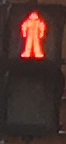

{'class_id': 0, 'class_name': 'pedestrian_traffic_light', 'confidence': 0.6945235729217529, 'bbox_xyxy': [2320, 767, 2386, 911], 'area': 9398, 'image_size': [4032, 3024]}


In [36]:
from ultralytics import YOLO
import os

# Modellpfad laden
if IN_COLAB:
    best_model_path = '/content/drive/MyDrive/Computer_Vision_Project/trained_models/1_Yolo_FineTuned/weights/best.pt'
else:
    best_model_path = './runs/detect/zebraassist_15images/weights/best.pt'

# Modell auf CPU initialisieren (dadurch keine CUDA-Fehler)
best_model = YOLO(best_model_path)
best_model.to('cpu')

# Testbild festlegen
if IN_COLAB:
    test_image = '/content/drive/MyDrive/Computer_Vision_Project/data/ZebrAssist_YOLO_PartialAnnotations/train/images/heon_IMG_0549.JPG'
else:
    test_image = '../data/ZebrAssist_YOLO_PartialAnnotations/train/images/heon_IMG_0549.JPG'

# Crop der größten Detektion
crop, info = crop_largest_detection(
    test_image,
    model=best_model,
    conf=0.35,
    iou=0.5,
    classes=None,           # oder z. B. [best_model.names.index("pedestrian_traffic_light")]
    return_numpy=False
)

if crop is None:
    print("No detections passed the filters.")
else:
    display(crop)  # falls in Notebook
    print(info)
    # Falls für anderes Modell mit bestimmter Größe gebraucht:
    # crop_resized = crop.resize((224, 224))  # PIL
